Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pypnm
import glob
import cv2
from PIL import Image
import os

%matplotlib inline
sns.set_theme(style="whitegrid")

Verificación de directorio

In [35]:
print(f"Directorio de trabajo: {os.getcwd()}")
if os.path.exists("../data/info_mias.csv"):
    print("✅ CSV de metadata encontrado.")
if os.path.exists("../data/raw/"):
    print(f"✅ Carpeta de imágenes encontrada con {len(os.listdir('../data/raw/'))} archivos.")

Directorio de trabajo: /home/carlos/Documents/Github/MIAS-Mammography-Classification/notebooks
✅ CSV de metadata encontrado.
✅ Carpeta de imágenes encontrada con 322 archivos.


Análisis exploratorio

Total de imágenes únicas: 322


,file_name,tissue_type,class,severity,target
0,mdb001,UNK,ABNORM,B,1
1,mdb002,UNK,ABNORM,B,1
2,mdb003,UNK,NORM,N,0
3,mdb004,UNK,NORM,N,0
4,mdb005,UNK,ABNORM,B,1



Conteo por Clase:
target
Normal     207
Benigno     62
Maligno     53
Name: count, dtype: int64


/tmp/ipykernel_105274/3177407194.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df, palette='magma')
/tmp/ipykernel_105274/3177407194.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal (0)', 'Benigno (1)', 'Maligno (2)'])


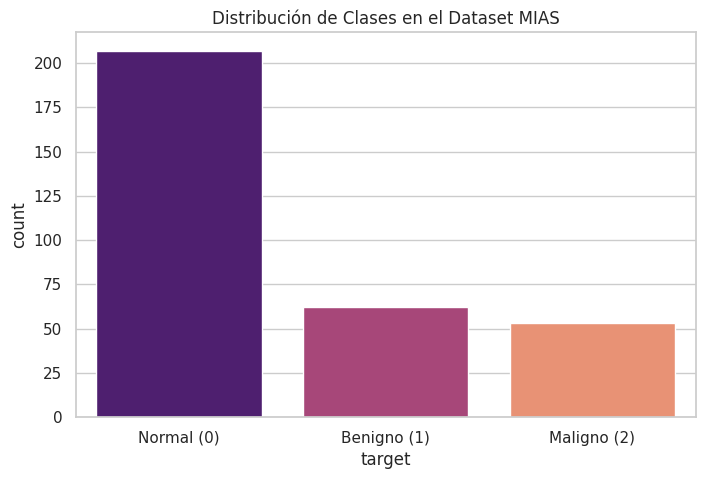

In [44]:
df = pd.read_csv('../data/info_mias.csv')

print(f"Total de imágenes únicas: {len(df)}")
display(df.head())

# 0: Normal, 1: Benigno, 2: Maligno
class_map = {0: 'Normal', 1: 'Benigno', 2: 'Maligno'}
print("\nConteo por Clase:")
print(df['target'].value_counts().rename(index=class_map))

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='target', data=df, palette='magma')
ax.set_title('Distribución de Clases en el Dataset MIAS')
ax.set_xticklabels(['Normal (0)', 'Benigno (1)', 'Maligno (2)'])
plt.show()

Prueba de carga con OpenCV

✅ Imagen mdb001 cargada exitosamente.
Dimensiones: (2048, 4320)


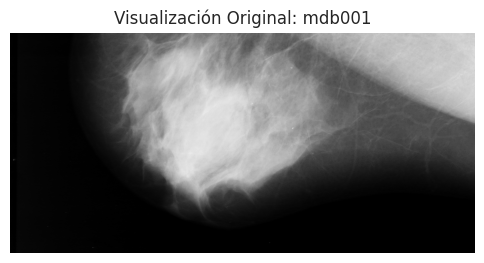

In [ ]:
def load_mammogram(img_id):
    """
    Busca y carga una imagen PGM usando OpenCV.
    """
    # Buscamos el archivo que empiece con el ID (ej: mdb001*.pgm)
    search_pattern = f"../data/raw/{img_id}*.pgm"
    files = glob.glob(search_pattern)
    
    if not files:
        print(f"❌ Error: No se encontró ningún archivo para el ID {img_id}")
        return None
    
    path = files[0] # Tomamos la primera coincidencia
    
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    
    if img is None:
        print(f"❌ Error: OpenCV no pudo leer el archivo en {path}")
        return None
        
    return img

sample_id = df.iloc[0]['file_name']
sample_img = load_mammogram(sample_id)

if sample_img is not None:
    print(f"✅ Imagen {sample_id} cargada exitosamente.")
    print(f"Dimensiones: {sample_img.shape}")
    plt.figure(figsize=(6,6))
    plt.imshow(sample_img, cmap='gray')
    plt.title(f"Visualización Original: {sample_id}")
    plt.axis('off')
    plt.show()

Preprocesamiento médico (CLAHE)

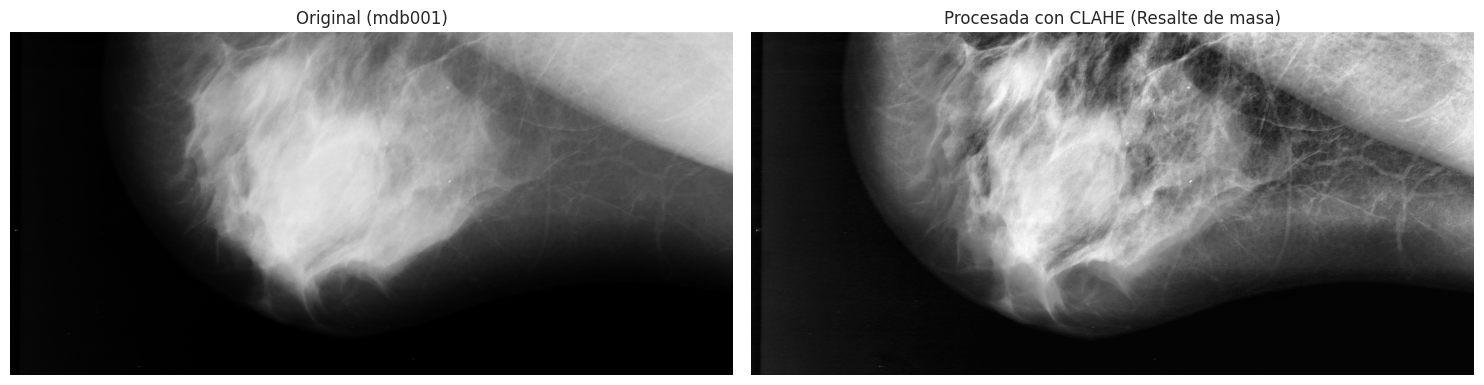

In [46]:
def apply_medical_preprocessing(img):
    # normalización a 8 bits 
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # aplicar CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced_img = clahe.apply(img_norm)
    
    return enhanced_img

if sample_img is not None:
    enhanced = apply_medical_preprocessing(sample_img)
    
    # Comparativa Visual
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    
    axes[0].imshow(sample_img, cmap='gray')
    axes[0].set_title(f"Original ({sample_id})")
    axes[0].axis('off')
    
    axes[1].imshow(enhanced, cmap='gray')
    axes[1].set_title("Procesada con CLAHE (Resalte de masa)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()